# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hilda Oktaviani
- **Email:** hildaoktaa24@gmail.com
- **ID Dicoding:** hilda_oktaviani

## Menentukan Pertanyaan Bisnis


- Pertanyaan 1 : Apakah faktor cuaca mempengaruhi penyewaan sepeda?
- Pertanyaan 2 : Berdasarkan musim dan hari, faktor apa yang menentukan titik tertinggi penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Membaca file csv

In [9]:
hour_url = "https://raw.githubusercontent.com/HildaOktaviani/Proyek-Analisis-Data/refs/heads/main/data/hour.csv"
hour_df = pd.read_csv(hour_url)

In [10]:
day_url = "https://raw.githubusercontent.com/HildaOktaviani/Proyek-Analisis-Data/refs/heads/main/data/day.csv"
day_df = pd.read_csv(day_url)

Menampilkan data frame dari file csv

In [11]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [12]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Berdasarkan data diatas, terlihat bahwa mayoritas penyewa sepeda adalah pelanggan tetap yang terdaftar
- Berdasarkan data diatas, penyewaan sepeda tampak dipengaruhi oleh suhu dan cuaca

### Assessing Data

Memeriksa apakah ada data dengan missing values

In [13]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [14]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Memeriksa duplikasi data

In [15]:
hour_df.duplicated().sum()

np.int64(0)

In [16]:
day_df.duplicated().sum()

np.int64(0)

Menampilkan tipe data

In [17]:
pd.to_datetime(hour_df['dteday'])

0       2011-01-01
1       2011-01-01
2       2011-01-01
3       2011-01-01
4       2011-01-01
           ...    
17374   2012-12-31
17375   2012-12-31
17376   2012-12-31
17377   2012-12-31
17378   2012-12-31
Name: dteday, Length: 17379, dtype: datetime64[ns]

In [18]:
pd.to_datetime(day_df['dteday'])


0     2011-01-01
1     2011-01-02
2     2011-01-03
3     2011-01-04
4     2011-01-05
         ...    
726   2012-12-27
727   2012-12-28
728   2012-12-29
729   2012-12-30
730   2012-12-31
Name: dteday, Length: 731, dtype: datetime64[ns]

Ringkasan statistik untuk mengidentifikasi potensi outlier

In [19]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [20]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Berdasarkan hasil wrangling data yang telah dilakukan, dapat dilihat bahwa dari kedua set data bersih dari missing value dan duplikasi, maka dapat disimpulkan bahwa data tersebut sudah cukup baik dari segi kelengkapan dan kualitas
- Berdasarkan deskripsi statistik, dapat dilihat bahwa cuaca memiliki pengaruh terhadap penyewaan sepeda

### Cleaning Data

Mengubah kolom date dtday menjadi format datetime

In [21]:
pd.to_datetime(day_df['dteday'])

0     2011-01-01
1     2011-01-02
2     2011-01-03
3     2011-01-04
4     2011-01-05
         ...    
726   2012-12-27
727   2012-12-28
728   2012-12-29
729   2012-12-30
730   2012-12-31
Name: dteday, Length: 731, dtype: datetime64[ns]

In [22]:
pd.to_datetime(hour_df['dteday'])

0       2011-01-01
1       2011-01-01
2       2011-01-01
3       2011-01-01
4       2011-01-01
           ...    
17374   2012-12-31
17375   2012-12-31
17376   2012-12-31
17377   2012-12-31
17378   2012-12-31
Name: dteday, Length: 17379, dtype: datetime64[ns]

Menyimpan dataset yang sudah bersih

In [24]:
## hour_df.to_csv('/content/clean_hour_df.csv')

In [25]:
## day_df.to_csv('/content/clean_day_df.csv')

## Exploratory Data Analysis (EDA)

### Explore ...

Menampilkan korelasi faktor cuaca dengan penyewaan sepeda

In [ ]:
day_df['weathersit'].value_counts()

,count
weathersit,
1,463
2,247
3,21


In [ ]:
hour_df['weathersit'].value_counts()

,count
weathersit,
1,11413
2,4544
3,1419
4,3


In [ ]:
day = day_df.groupby('weathersit')['cnt'].mean()

day

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


In [ ]:
hour = hour_df.groupby('weathersit')['cnt'].mean()

hour

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


Korelasi musim dengan penyewaan sepeda

In [ ]:
musim_rental = day_df.groupby('season')['cnt'].mean().reset_index()
musim_rental

,season,cnt
0,1,2604.132597
1,2,4992.331522
2,3,5644.303191
3,4,4728.162921


Korelasi perbedaan hari libur dan hari kerja dengan penyewaan sepeda

In [ ]:
hari_kerja = day_df.groupby('workingday')['cnt'].mean().reset_index()
hari_kerja

,workingday,cnt
0,0,4330.168831
1,1,4584.820000


In [ ]:
hari_libur = day_df.groupby('holiday')['cnt'].mean().reset_index()
hari_libur

,holiday,cnt
0,0,4527.104225
1,1,3735.000000


**Insight:**
- Dapat dilihat berdasarkan data suhu (temperatur) memiliki pengaruh cukup besar terhadap penyewaan sepeda.
- Berdasarkan hasil explorasi data, dapat dilihat bahwa musim panas dan hari kerja memiliki rata-rata penyewaan cukup tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana faktor cuaca dapat mempengaruhi tinggi rendahnya tingkat penyewaan sepeda?

In [ ]:
print(day.index)

Index([1, 2, 3], dtype='int64', name='weathersit')


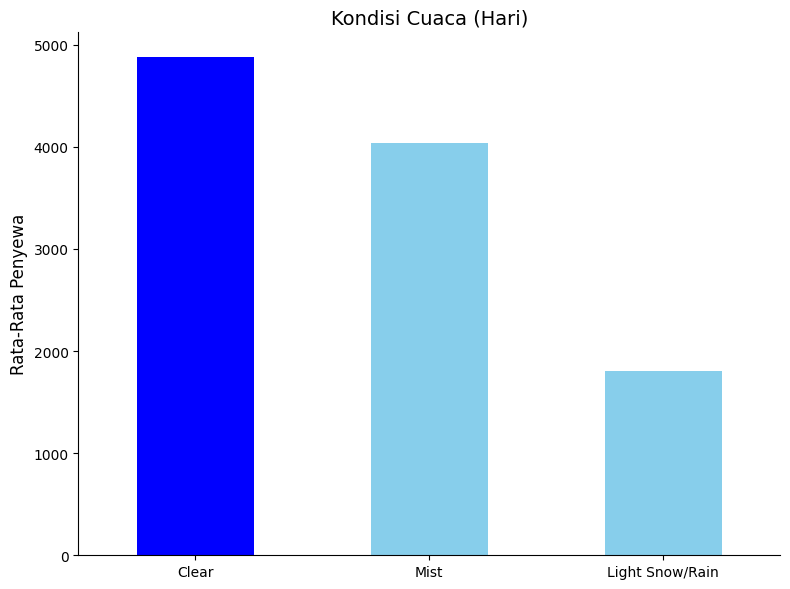

In [ ]:
if day.index.dtype != "object":
    weather_labels = {1: "Clear", 2: "Mist", 3: "Light Snow/Rain", 4: "Heavy Rain"}
    day.index = day.index.map(weather_labels)

plt.figure(figsize=(8, 6))
ax = day.plot(kind="bar", color="skyblue")

for bar, label in zip(ax.patches, day.index):
    if label == "Clear":
        bar.set_facecolor("blue")

plt.title("Kondisi Cuaca (Hari)", fontsize=14)
plt.xlabel("")
plt.ylabel("Rata-Rata Penyewa", fontsize=12)
plt.xticks(rotation=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")

plt.tight_layout()
plt.show()

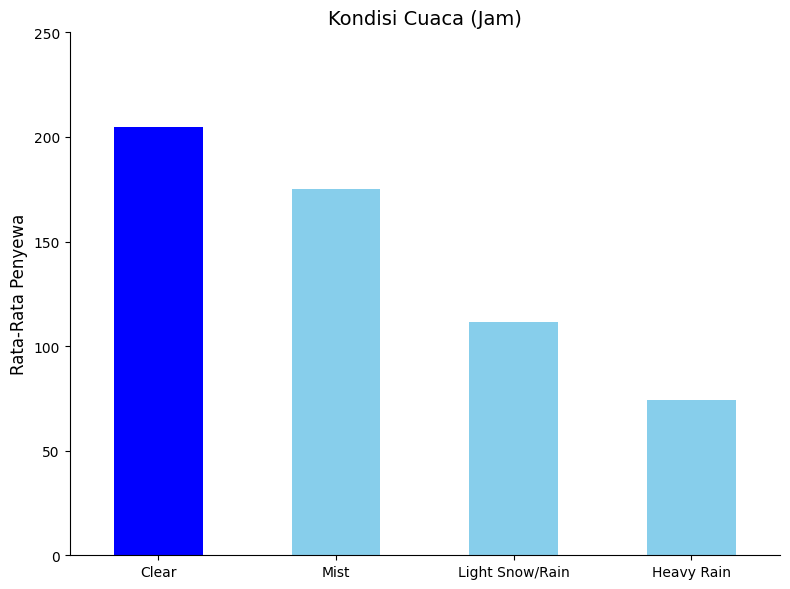

In [ ]:
weather_labels = {1: "Clear", 2: "Mist", 3: "Light Snow/Rain", 4: "Heavy Rain"}
hour.index = hour.index.map(weather_labels)
plt.figure(figsize=(8, 6))

ax = hour.plot(kind="bar", color="skyblue")
for bar, label in zip(ax.patches, hour.index):
    if label == "Clear":
        bar.set_facecolor("blue")

plt.title("Kondisi Cuaca (Jam)", fontsize=14)
plt.xlabel("")
plt.ylabel("Rata-Rata Penyewa", fontsize=12)
plt.xticks(rotation=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
plt.ylim(0, 250)

plt.tight_layout()
plt.show()


### Pertanyaan 2:

Faktor apa yang menentukan titik tertinggi penyewaan sepeda?

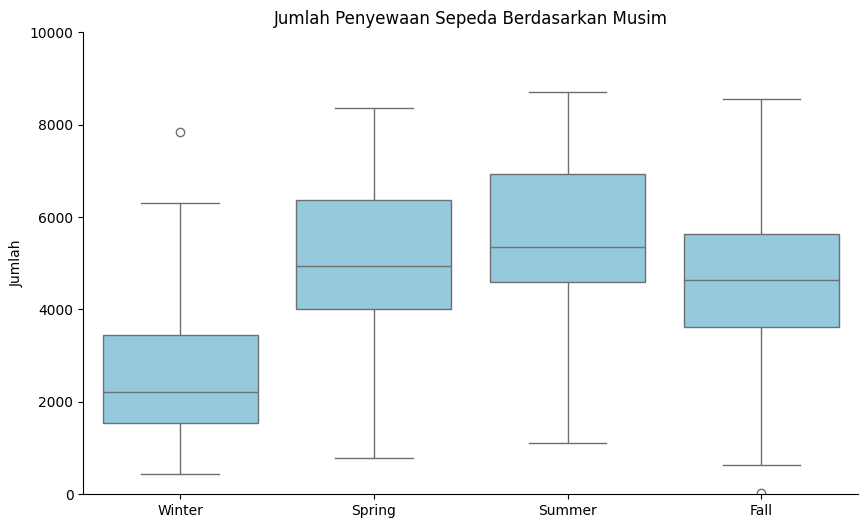

In [ ]:
season_labels = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
day_df["season_label"] = day_df["season"].map(season_labels)

plt.figure(figsize=(10, 6))
plt.ylim(0, 10000)
ax = sns.boxplot(x="season_label", y="cnt", data=day_df, color="skyblue")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color("black")
ax.spines['left'].set_color("black")

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Musim", color="black")
plt.xlabel("")
plt.ylabel("Jumlah", color="black")

ax.tick_params(axis='x', colors="black")
ax.tick_params(axis='y', colors="black")

plt.show()

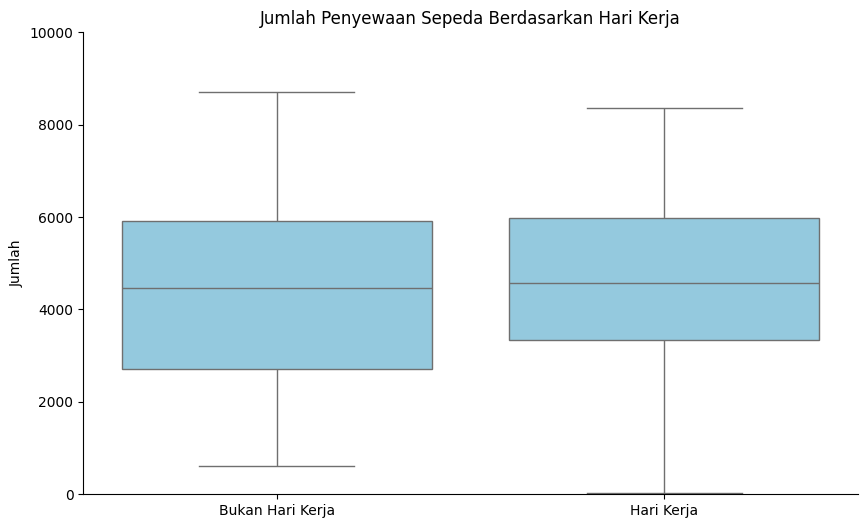

In [ ]:
day_df["workingday_label"] = day_df["workingday"].map({0: "Bukan Hari Kerja", 1: "Hari Kerja"})
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x="workingday_label", y="cnt", data=day_df, color="skyblue")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color("black")
ax.spines['left'].set_color("black")
plt.ylim(0, 10000)

plt.xlabel("")

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Hari Kerja", color="black")
plt.ylabel("Jumlah", color="black")

ax.tick_params(axis='x', colors="black")
ax.tick_params(axis='y', colors="black")

plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
correlation_matrix = day_df[['season', 'workingday', 'cnt']].corr()

<Figure size 1000x600 with 0 Axes>

<Axes: >

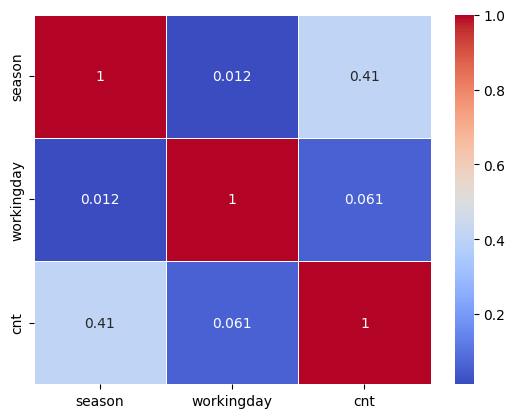

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

**Insight:**
- Berdasarkan hasil visualisasi data tersebut, dapat dilihat bahwa cuaca memiliki korelasi positif terhadap penyewaan sepeda, berdasarkan data diatas semakin baik kondisi cuaca maka semakin banyak sepeda yang di sewa
- Perubahan musim dan perbedaan antara hari kerja dengan hari libur mempengaruhi penyewaan sepeda

# **Clustering Tanpa Machine Learning**

## **Teknik Manual Grouping**

Dataset Bike sharing cocok menggunakan teknik manual grouping karena kategori seperti musim, jenis hari, dan kondisi cuaca memiliki jumlah kelas terbatas yang jelas, sehingga mempermudah analisis pola penyewaan sepeda.

In [ ]:
# Mapping musim ke kategori

season_mapping = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
day_df["season_category"] = day_df["season"].map(season_mapping)

In [ ]:
# Kategorisasi hari (Holiday, Working Day, Weekend)

def categorize_day(row):
    if row["holiday"] == 1:
        return "Holiday"
    elif row["workingday"] == 1:
        return "Working Day"
    else:
        return "Weekend"

In [ ]:
day_df["day_type"] = day_df.apply(categorize_day, axis=1)

<ipython-input-226-9b9571c2f356>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="season_category", y="cnt", data=day_df, ci=None, color="lightblue")


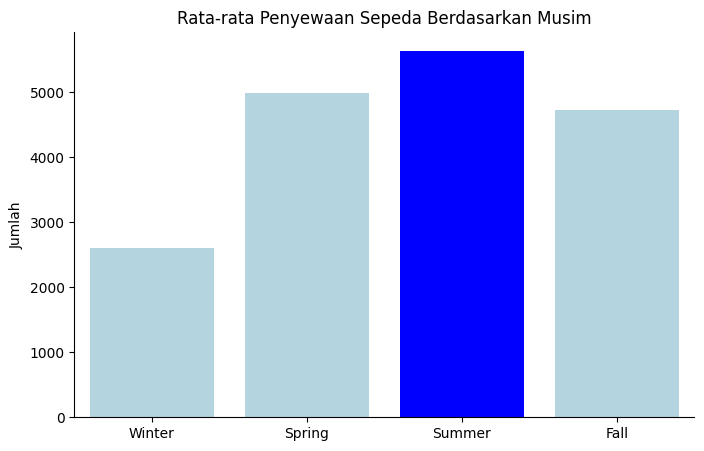

In [ ]:
# Visualisasi jumlah penyewaan berdasarkan musim

plt.figure(figsize=(8, 5))
ax = sns.barplot(x="season_category", y="cnt", data=day_df, ci=None, color="lightblue")
for bar, label in zip(ax.patches, day_df["season_category"].unique()):
    if label == "Summer":
        bar.set_facecolor("blue")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.spines['bottom'].set_color("black")
ax.spines['left'].set_color("black")

ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")

ax.tick_params(axis='x', colors="black")
ax.tick_params(axis='y', colors="black")

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim", color="black")
plt.xlabel("")
plt.ylabel("Jumlah")
plt.show()

<ipython-input-228-e2217161d0d7>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="day_type", y="cnt", data=day_df, ci=None, color="lightblue")


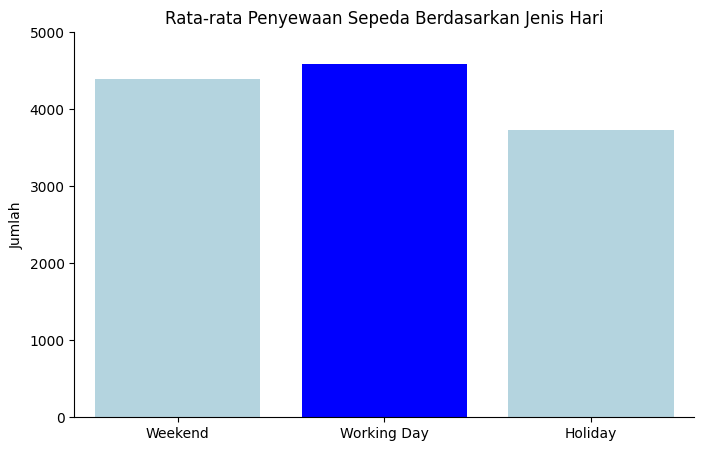

In [ ]:
# Visualisasi jumlah penyewaan berdasarkan jenis hari

plt.figure(figsize=(8, 5))
ax = sns.barplot(x="day_type", y="cnt", data=day_df, ci=None, color="lightblue")
for bar, label in zip(ax.patches, day_df["day_type"].unique()):
    if label == "Working Day":
        bar.set_facecolor("blue")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color("black")
ax.spines['left'].set_color("black")
plt.ylim(0, 5000)

ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")

ax.tick_params(axis='x', colors="black")
ax.tick_params(axis='y', colors="black")

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jenis Hari", color="black")
plt.xlabel("")
plt.ylabel("Jumlah")
plt.show()

**Insight**



Berdasarkan hasil analisis data menggunakan teknik manual grouping, dapat dilihat pada visualisasi data bahwa musim panas (summer) dan hari kerja (working day) merupakan periode dengan jumlah penyewaan sepeda tertinggi.

## Conclusion

- Conclution pertanyaan 1
  
  Berdasarkan hasil dari analisis, cuaca memiliki dampak besar terhadap penyewaan sepeda yang cenderung turun saat cuaca buruk. Bagi penyedia layanan sepeda, hal ini mungkin bisa menjadi perhatian betapa pentingnya penggunaan prakiraan cuaca untuk merencanakan operasional dan pemasaran, dengan fokus pada kondisi cuaca cerah sebagai momen puncak untuk meningkatkan penggunaan layanan.

- Conclution pertanyaan 2

  Berdasarkan data yang telah dianalisis dan divualisasikan, musim panas dan hari kerja menunjukan bahwa kedua faktor tersebut adalah yang paling mempengaruhi titik tertinggi penyewaan sepeda.




Kesimpulan akhirnya adalah, pada hari kerja dengan cuaca yang baik pada saat musim panas mungkin ada baiknya bagi pemilik rental untuk menambah stok sepeda. Hal ini tentunya karena tingginya penyewa pada ketiga faktor tersebut dapat menguntungkan pemilik rental.